In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('./nshtrack.npz', allow_pickle=True)

print(data)

In [6]:
time = data["time"]
state= data["state"]
params = data["params"]
model_idx = data["model_index"]
ctrl = data["ctrl"]

x = state[:, 0]
y = state[:, 1]
theta = state[:, 2]
dx = state[:, 3]
dy = state[:, 4]
omega = state[:, 5]

print(len(x))

1053


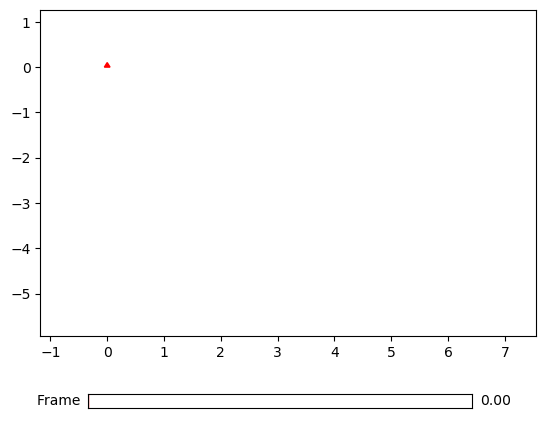

In [4]:
from matplotlib.widgets import Slider

# Set up figure
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.2)  # leave space for slider
point, = ax.plot([], [], 'bo')  # car position
arrow = ax.arrow(0, 0, 0, 0, head_width=0.1, head_length=0.1, fc='red', ec='red')
ax.set_xlim(min(x)-1, max(x)+1)
ax.set_ylim(min(y)-1, max(y)+1)
title = ax.set_title("")

# Slider
ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])
frame_slider = Slider(ax_slider, 'Frame', 0, len(x)-1, valinit=0, valstep=1)

def update(val):
    i = int(frame_slider.val)
    ax.clear()
    ax.set_xlim(min(x)-1, max(x)+1)
    ax.set_ylim(min(y)-1, max(y)+1)
    ax.set_title(f"Frame {i}: θ={theta[i]:.2f}, dx={dx[i]:.2f}, dy={dy[i]:.2f}, ω={omega[i]:.2f}")
    ax.scatter(x[i], y[i], color='blue', s=50)
    ax.arrow(x[i], y[i], 0.5*np.cos(theta[i]), 0.5*np.sin(theta[i]),
             head_width=0.1, head_length=0.1, fc='red', ec='red')

frame_slider.on_changed(update)

plt.show()